# Neural Computation Coursework - Group 30

## Table of Contents

<ul>
    <li>
        <a href="#introduction">Introduction</a>
    </li>
    <li>
        <a href="#implementation">Implementation</a>
    </li>
        <ul>
            <li>
                <a href="#fcn">Fully Convolutional Network (FCN)</a>
            </li>
                <ul>
                    <li>
                        <a href="#fcn-outline">Outline</a>                    
                    </li>
                    <li>
                        <a href="#fcn-architecture">Architecture</a>
                    </li>
                    <li>
                        <a href="#fcn-implementation">Implementation</a>                    
                    </li>
                    <li>
                        <a href="#fcn-experimentation">Experimentation</a>                    
                    </li>
                </ul>
            <li>
                <a href="unet">U-Net</a>
            </li>
                <ul>
                    <li>
                        <a href="#unet-outline">Outline</a>
                    </li>
                    <li>
                        <a href="#unet-architecture">Architecture</a>
                    </li>
                    <li>
                        <a href="#unet-implementation">Implementation</a>
                    </li>
                    <li>
                        <a href="#unet-experimentation">Experimentation</a>
                    </li>
                </ul>
        </ul>
    <li>
        <a href="#experiments">Experiments</a>
    </li>
    <li>
        <a href="#conclusion">Conclusion</a>
    </li>
    <li>
        <a href="#source-code">Source Code</a>
    </li>
</ul>

<h2 id="introduction">Introduction</h2>

For this assignment, our task is to develop a convolutional neural network to perform image segmentation on an MR of a cardiovascular image. We were told to break it down into 4 regions: background, left ventricle, right ventricle and the myocardium. 

For most of the data we received, we had a pair of two images: one which was the original scan image and the other an output mask, which was done by a person manually. To produce this network, we utilised a dataset of 200 images, with 100 being used for training, 20 for validation and 80 for testing. The training set will be used to train the model’s parameters to fit it for a segmentation task for images of this type. The validation set will be used for tweaking the hyper-parameters that the network uses to train its parameters by comparing models that used different hyper-parameter values. The purpose of this is to use data that is unseen to compare the generalisation of the different models.

For the test image dataset, we received only the original image and not a corresponding mask. These were used to evaluate how the network generalised being trained with its hyper-parameters tuned. This ensures that the hyper-parameters chosen did not happen to overfit for the validation dataset.

At the end, we hope to receive a model which is accurate and works in a short amount of time. Reaching this goal will help clinicians to derive measures involving the different segments we’ve produced much easier, allowing them to finish their work faster, allowing them to diagnose, and help heal patients more efficiently. 

<h2 id="implementation">Implementation</h2>

To arrive at the most accurate architecture for the given problem, we decided to experiment with two different architecture types: Fully Convolutional Networks (FCNs) and U-Net. We narrowed the selection down to these two particular models after careful evaluation and thorough research on the most effective and popular approaches to image segmentation problems.

<h3 id="fcn">Fully Convolutional Network (FCN)</h3>

<h4 id="fcn-outline">Outline</h4>

FCNs normally operate on inputs of any size and produce an output with corresponding dimensions. Moreover, FCN is the most commonly used architecture for image segmentation tasks, which makes it a clear candidate for solving this problem. We decided to implement an FCN-8 solution as part of our experiments.

<figure>
    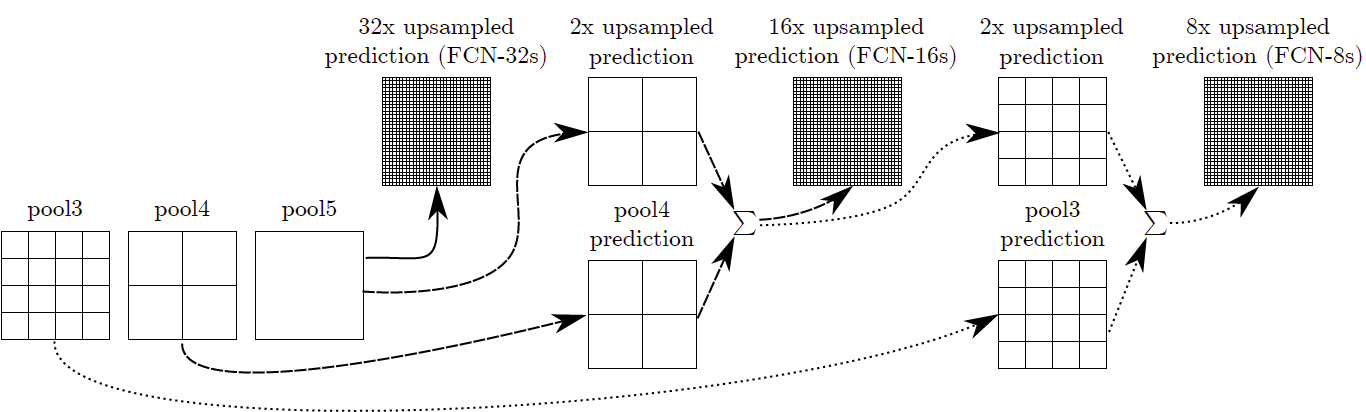
    <figcaption style="text-align: left;">Figure 1: Fusing for FCN-16s and FCN-8s (Tsang, 2018)</figcaption>
</figure>

<h4 id="fcn-architecture">Architecture</h4>

The diagram above illustrates the core design of FCNs. Starting off with FCN-32, we take the fifth pooling layer (pool5) and up-sample it to produce an output that is then up-sampled 32 times to serve as the predicted output for this particular FCN version. Next, we add up a 2x up-sampled prediction of the fifth pooling layer (pool5) along with the fourth pooling layer (pool4) (sum1) to produce a 16x up-sampled prediction for FCN-16. Finally, the third pooling layer (pool3)  is summed up with the 2x up-sampled sum1 to produce the 8x up-sampled predicted output for FCN-8.



<h4 id="fcn-implementation">Implementation</h4>

The PyTorch implementation of this architecture that we used consists of five convolutional layers followed by two fully-connected layers. It uses Adam as an optimiser, with learning rate 0.001, and Cross-Entropy as the loss function. These two hyper-parameters were chosen after multiple rounds of trialling.

We refrained from initialising the weights because it yielded no contributing outcome. The model, instead, learns the weights through the use of the optimiser we used (Adam).

We translated the aforementioned diagram (Figure 1) to Python (Huan, 2020) to arrive at the FCN-8 model as seen below:



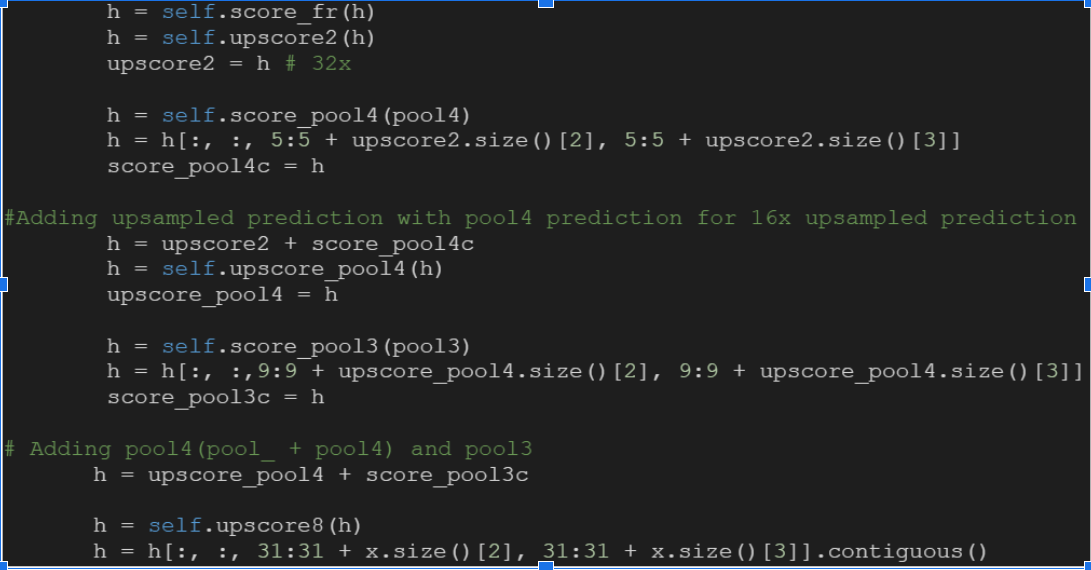


The following code is taken from the portion of the code where the model is initially designed. After the five convolution layers and two fully-connected layers are defined, the forward function displayed below is used to upscore different layers and compute the corresponding sums (as described in the Architecture section above):

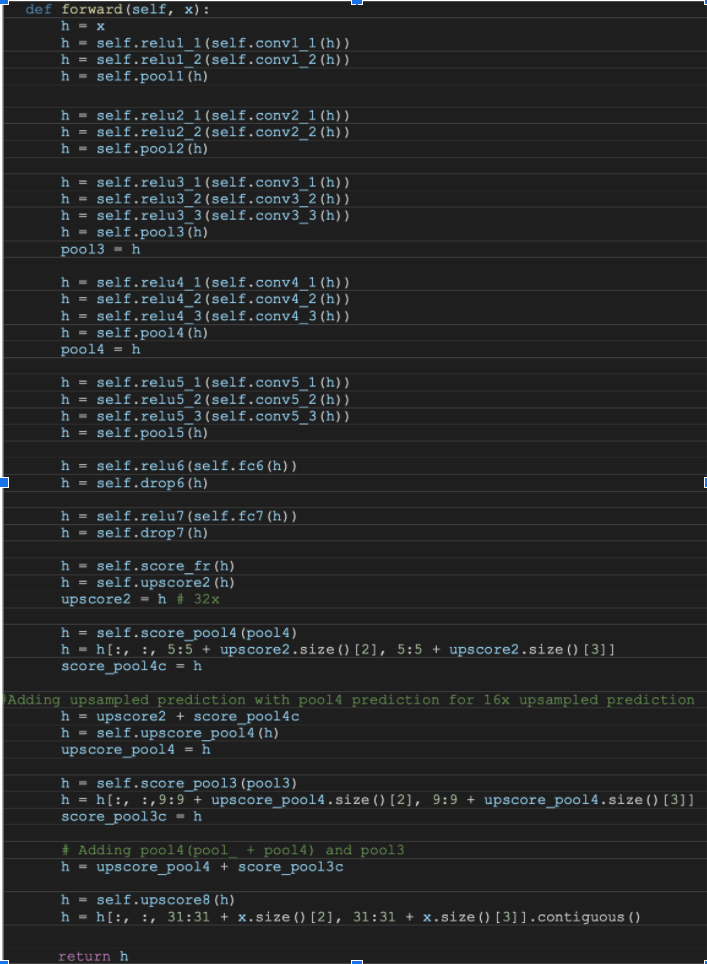

<h4 id="fcn-experimentation">Experimentation</h4>

When training the model, we used the training dataset provided; we chose to do that with a hundred epochs such as to avoid the possibility of overfitting and under-fitting the training data. This is because using a higher number of epochs yielded more accurate results during training; however, the same could not be said during testing and validation, where we noticed a significant decrease in output accuracy. On the contrary, using an insufficient number of epochs lead to the model not learning enough about the data, and therefore not being able to represent an adequate segmentation map on any of the datasets. Another preventative measure we used against overfitting was Dropout at each update in the fully-connected layers after linearisation. Dropout is a technique used to restrain a model from overfitting by randomly assigning the outgoing hidden neurons to zero.

<h3 id="fcn">U-Net</h3>

<h4 id="unet-outline">Outline</h4>

U-Net is a convolutional network that is commonly used in Biomedical Image Segmentation due to its quick and accurate segmentation. U-Net learns segmentation in an end-to-end setting, meaning a raw image in and a segmented image out. The key concept behind U-Net is when converting a vector back into an image, use the same feature mapping from what was used in image to vector.

<figure>
    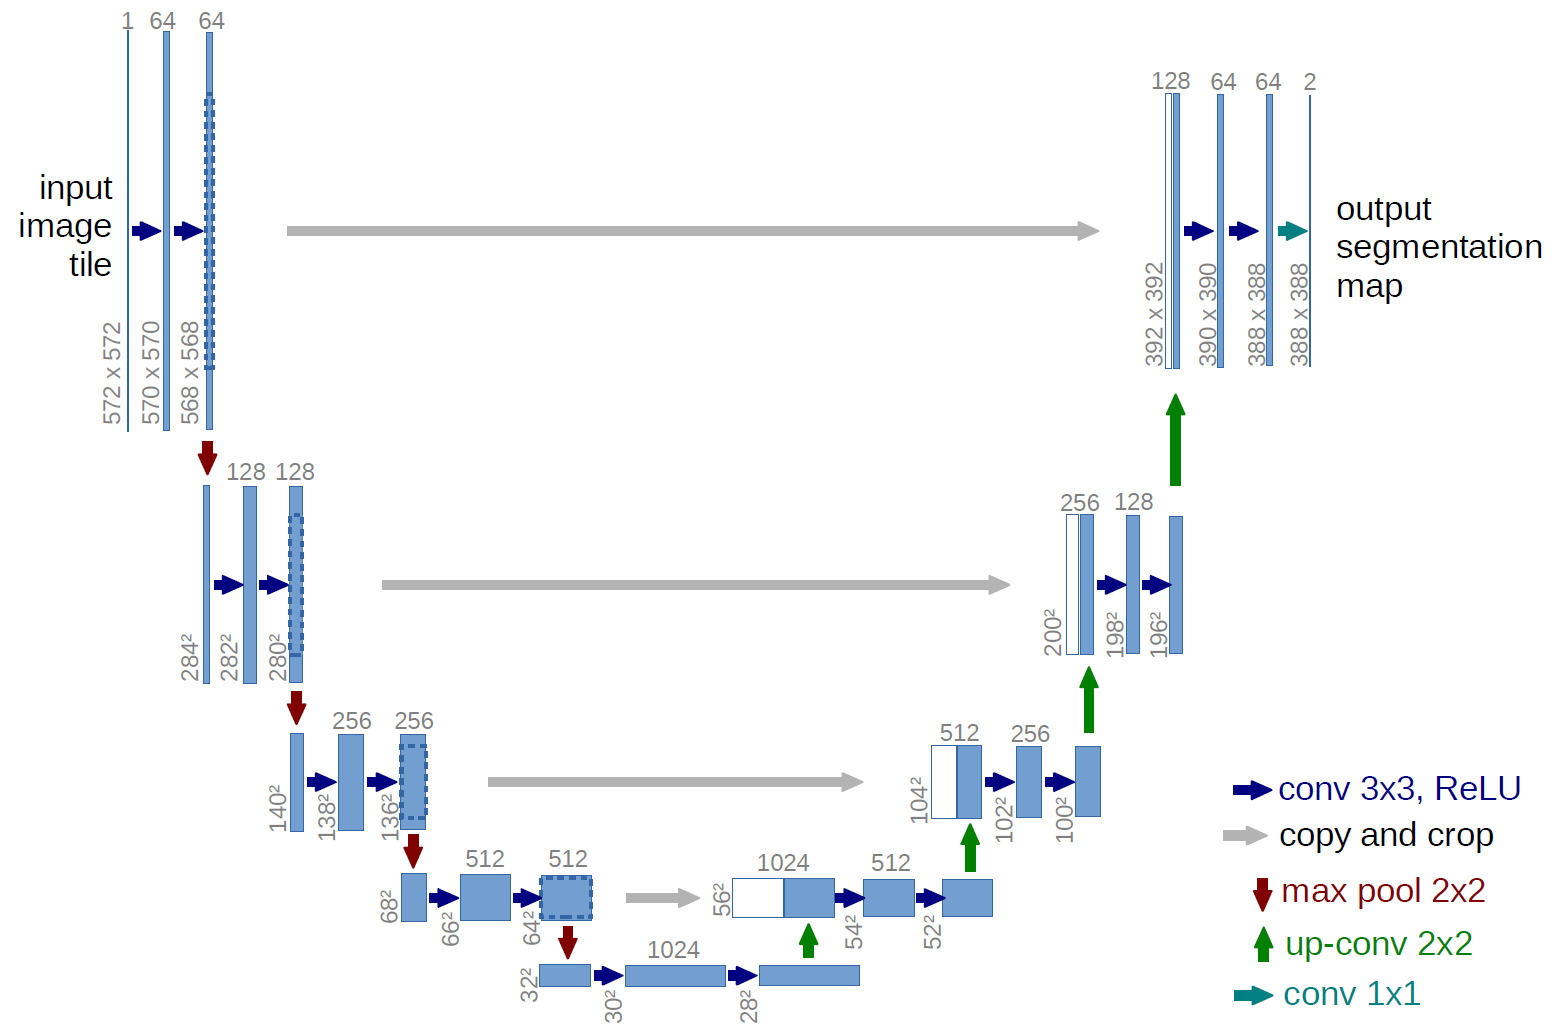
    <figcaption style="text-align: left;">Figure 2: U-Net architecture - (Ronneberger et al., 2011)</figcaption>
</figure>

<h4 id="unet-architecture">Architecture</h4>

The reference here uses a 3x3 convolution with ReLU. This means that for each 3x3 convolution,  a single pixel border is lost (9 pixels to 1 pixel). This will allow large images to be processed more easily (in a smaller size).

A max pooling function is then applied to reduce the size/resolution of the feature map. This acts on each channel separately, iteratively processing the single maximum activation in a (2x2) frame.

After each max pooling operation, we increase the number of feature channels (per feature map) by a factor of 2. The diagram shows 5 layers of this process occurring, decreasing the dimensional space of the feature maps. By doing this, we are able to identify elements more accurately with much less knowledge of the location as this initial process is just for classification.

Once the feature maps have reached the final layer of convolution, a series of up-convolutions take place. The up-convolution maps each feature vector to create a 2x2 pixel output frame (followed by ReLU). This process repeats the same number of iterations as the (down-)convolutions to reach the Output segmentation map).

The trick behind U-Net is that when the up-convolutions occur, for each single block at each layer, the correlating feature map (of the equivalent size from the down-convolution) is appended to the reconstruction in order to maintain the features learned during the down-convolution.

The output class would contain the number of feature maps equivalent to the number of wanted segments. Here the output has 4 channels (one for each class). The crop feature is used to match the size of the feature maps from the contracting path with the feature maps produced from the upsampling on the expansive patch. This is due to the pixels that are lost when using the convolution operation without using  ‘same’ padding.

Evaluation this architecture, the model would not achieve as good a result if the image contains a low contrast between elements. This is because  it relies on this structural separation between elements to be able to identify them effectively. During the convolution and max pooling, low contrast areas could easily appear to represent a darker/different element rather than the true element in the training image.

With the correct hyper-parameter tuning and architectural structure, the model is able to accurately identify clear borders even in closely overlying sections.

<h4 id="unet-findings">Findings</h4>

After examining the results provided by FCN with varying hyper-parameters and comparing these findings to the products of the U-Net implementation, we came to the conclusion that the better approach for this problem would be to apply a U-Net model. This is backed by the dice score results of each model: we noticed a great difference in performance between the two models, with U-Net scoring between 0.87 - 0.9, whereas FCN would score in the range 0.44 - 0.5. This makes U-Net the clear contender for this image segmentation problem.

<h4 id="unet-implementation">Implementation</h4>

The initial model was based on using the same U-Net architecture as described in the U-Net: Convolutional Networks for Biomedical Image Segmentation paper. This consists of 4 downsampling blocks followed by 4 upsampling blocks. Both the downsampling and upsampling blocks use a double convolution so we implemented a class for it to reduce repeated code.

The class contains  2 convolutions with a 3x3 kernel and a stride of 2, each followed by a ReLU activation function. Same padding is applied to keep the width and height dimensions the same after the double convolution. This is useful when concatenating it with the feature maps from the initial upconvolutions because their sizes match and doesn’t require a cropping function.

Batch normalisation has also been applied to normalise the outputs after each convolution to stabilize the learning process. 

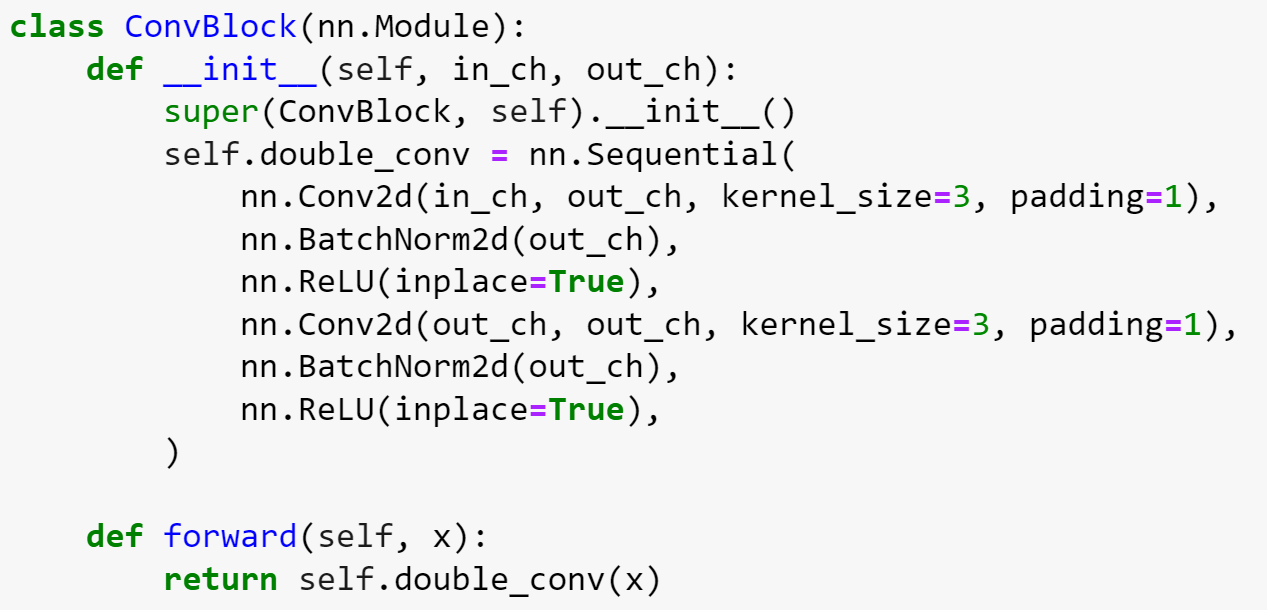

The encoder block contains a max pooling operation of size 2x2 followed by a convblock. The decoder block first concatenates the corresponding feature maps from the contracting path and the feature maps produced from the transposed convolution. 

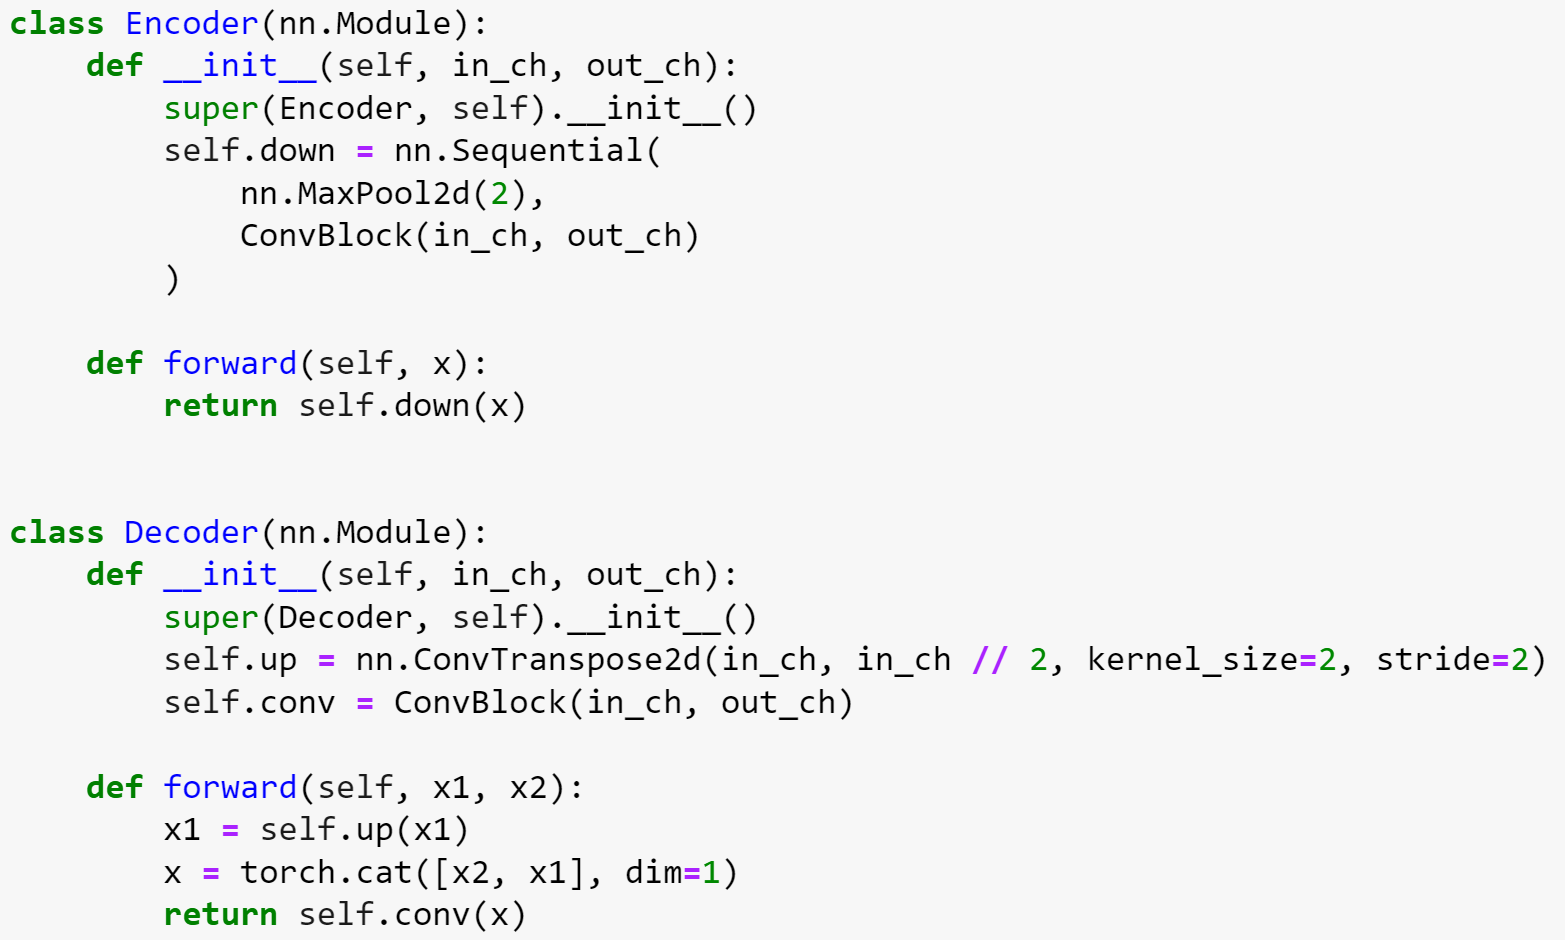

Finally these classes are combined to produce the full U-Net model. First a convolution block is applied followed by 4 decoder blocks for the contracting path. Then 4 decoder blocks are added for the expanding path. A final convolution is applied to reduce the number of channels to the corresponding number of output classes 4.

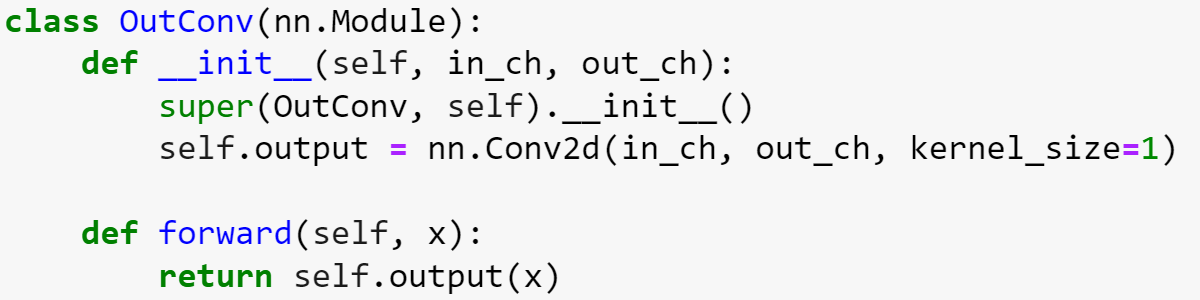

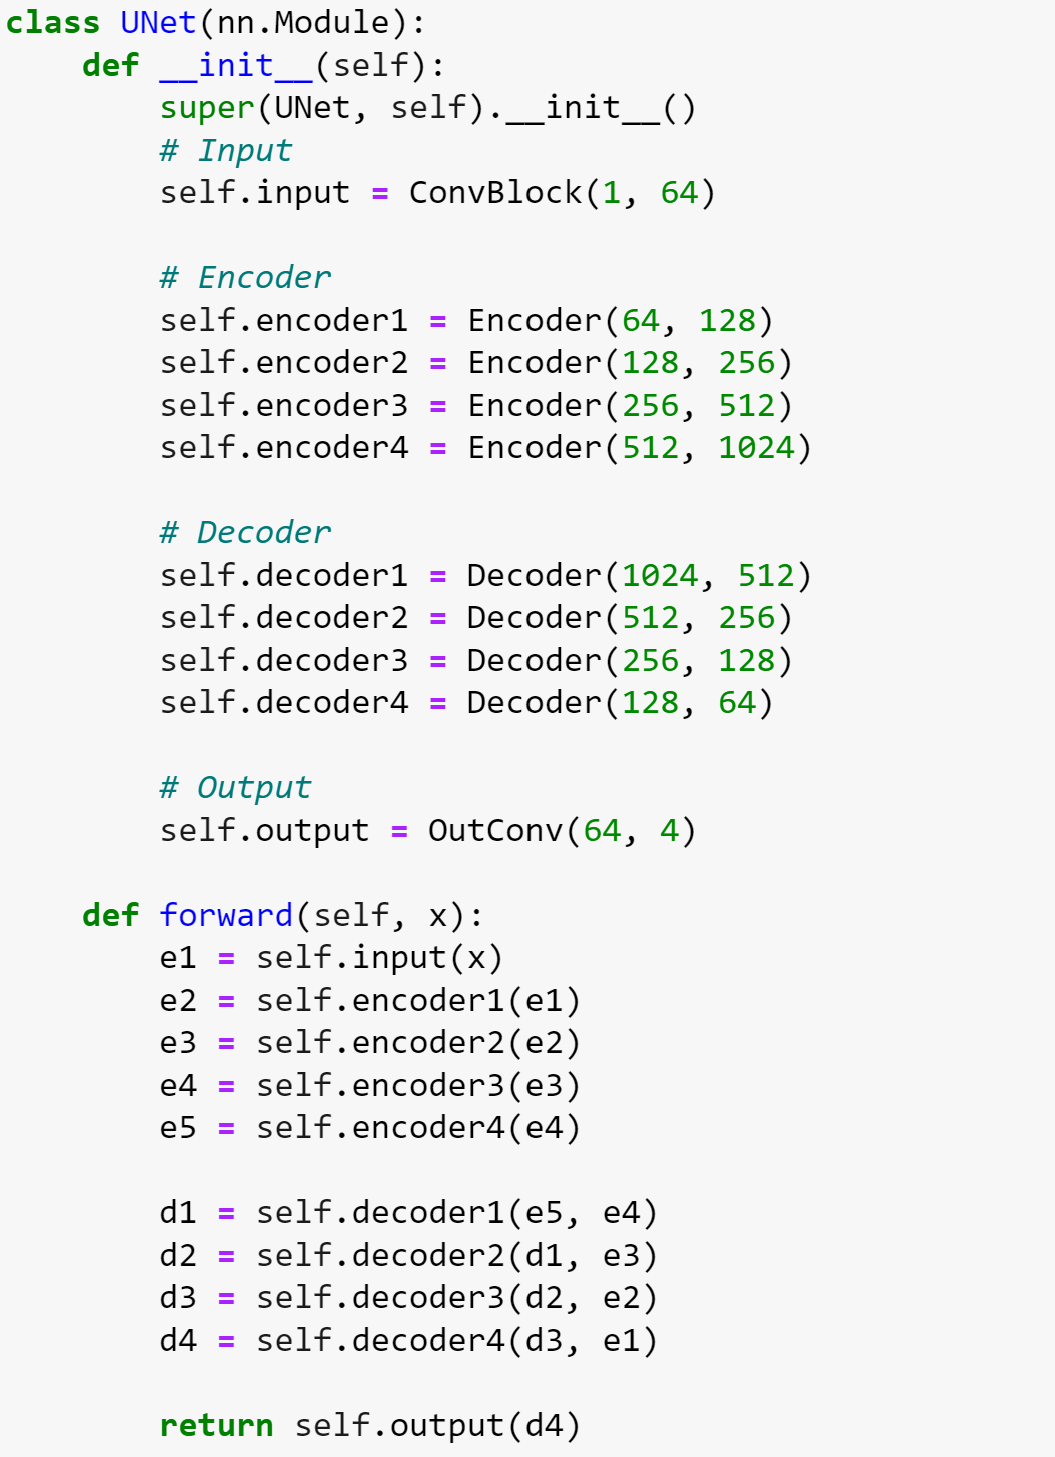

Regarding the training of the model, we choose to train and validate the model in the same epoch. We first train the model on the training dataset, then validate the resulting model on the validation dataset in the same epoch loop. This technique allow us to get only the best model after the epoch loop. Thus, we did not need to worry about choosing number of the epochs.

<h4 id="unet-experimentation">Experimentation</h4>

After trialling with a handful of different hyperparameter values for both models, looking at the results obtained, we concluded that U-Net performed better overall and thus we focused on this architecture for the remainder of our experiments.Once we gained our implemented model that delivered satisfactory results, we went on to tune a group of its hyper-parameters to assess whether there could be any further improvements made to the segmentation results. From all the hyper-parameters, we found two groups that had the most significant effect on the model: one group impacted the structure through parameters such as number of layers, activation functions, and dropout layers and the other refined the loss and optimiser functions used with specific values in their parameters.

In an attempt to enhance the structure of the model, we first trained it with varying  numbers of layers ranging from 2 to 5.  At each layer, two activation functions are implemented: ReLU and sigmoid. The most successful model was then tweaked by adding a dropout layer after each double convolution with different values to reduce overfitting. 

<figure>
    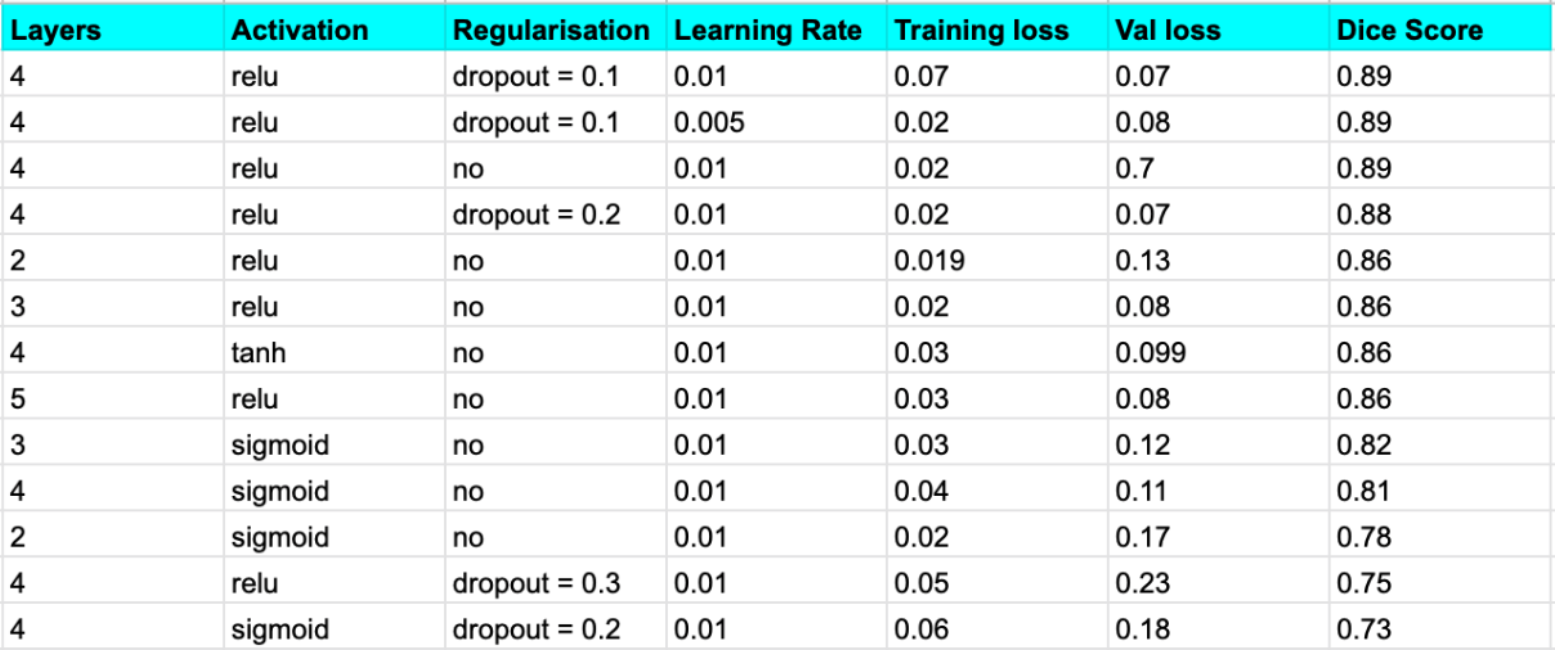
    <figcaption style="text-align: left;">Table 1: Model structure hyper-parameter tuning</figcaption>
</figure>

From the results obtained, the model with 4 layers performed the best as seen in the table above. However, the number of layers didn’t impact the dice score significantly. Activation functions had much more of an impact, with ReLU performing better than sigmoid at every layer. After finding that 4 layers and ReLU performed the best, dropout was implemented with values 0.1, 0.2, 0.3. While values of 0.1 and 0.2 performed as well as the base model there was no further improvement by using dropout and the models with 0.3 had poor performance and not fitting the data well.

After working with the overarching structure of the model, we then proceeded to fine-tune the model by tweaking the criterion and optimisation values. With regards to the criterion values, we trialled various options, starting with the most basic one which was Cross-Entropy. In addition to that, we also experimented with MSE(Mean-Squared Error), L1 and NLLLoss. We chose to trial the most commonly used optimisers: Adam, Adagrad, ASGD and SGD. For each criterion value, we alternated between these four optimizer functions for testing. We then proceeded to change some of the parameters such as learning rate, weight_decay etc. In the case of high performing models such as the one in the first row of Table 2, we isolated parameter values that we thought may be affecting the final dice score. For instance, we used Cross-Entropy loss with Adam as the optimizer and initially tested with learning rate as 0.001. As seen in the table the resulting dice score produced was 0.880. In the next experiment, we kept the learning rate as 0.001 as a control value and then added two more parameter values, as seen in the first row of Table 2. Adding the amsgrad and weight_decay parameters, we observe a slightly higher dice score. Thus, we chose the model that uses Cross-Entropy loss and Adam with learning rate as 0.001, amsgrad as True and weight_decay set to 1e-8. The remaining criterion values(MSE,L1 and NLLLoss) were also trialled with the same four optimizer values, however they did not seem to produce high dice score values. Altering parameter values for these criterion/optimizer pairs also proved to be unfruitful. Thus, we concluded that using Cross-Entropy Loss with Adam as an optimizer with learning rate 0.001 was the best criterion/optimizer pair that gave us the result we were looking for.

<figure>
    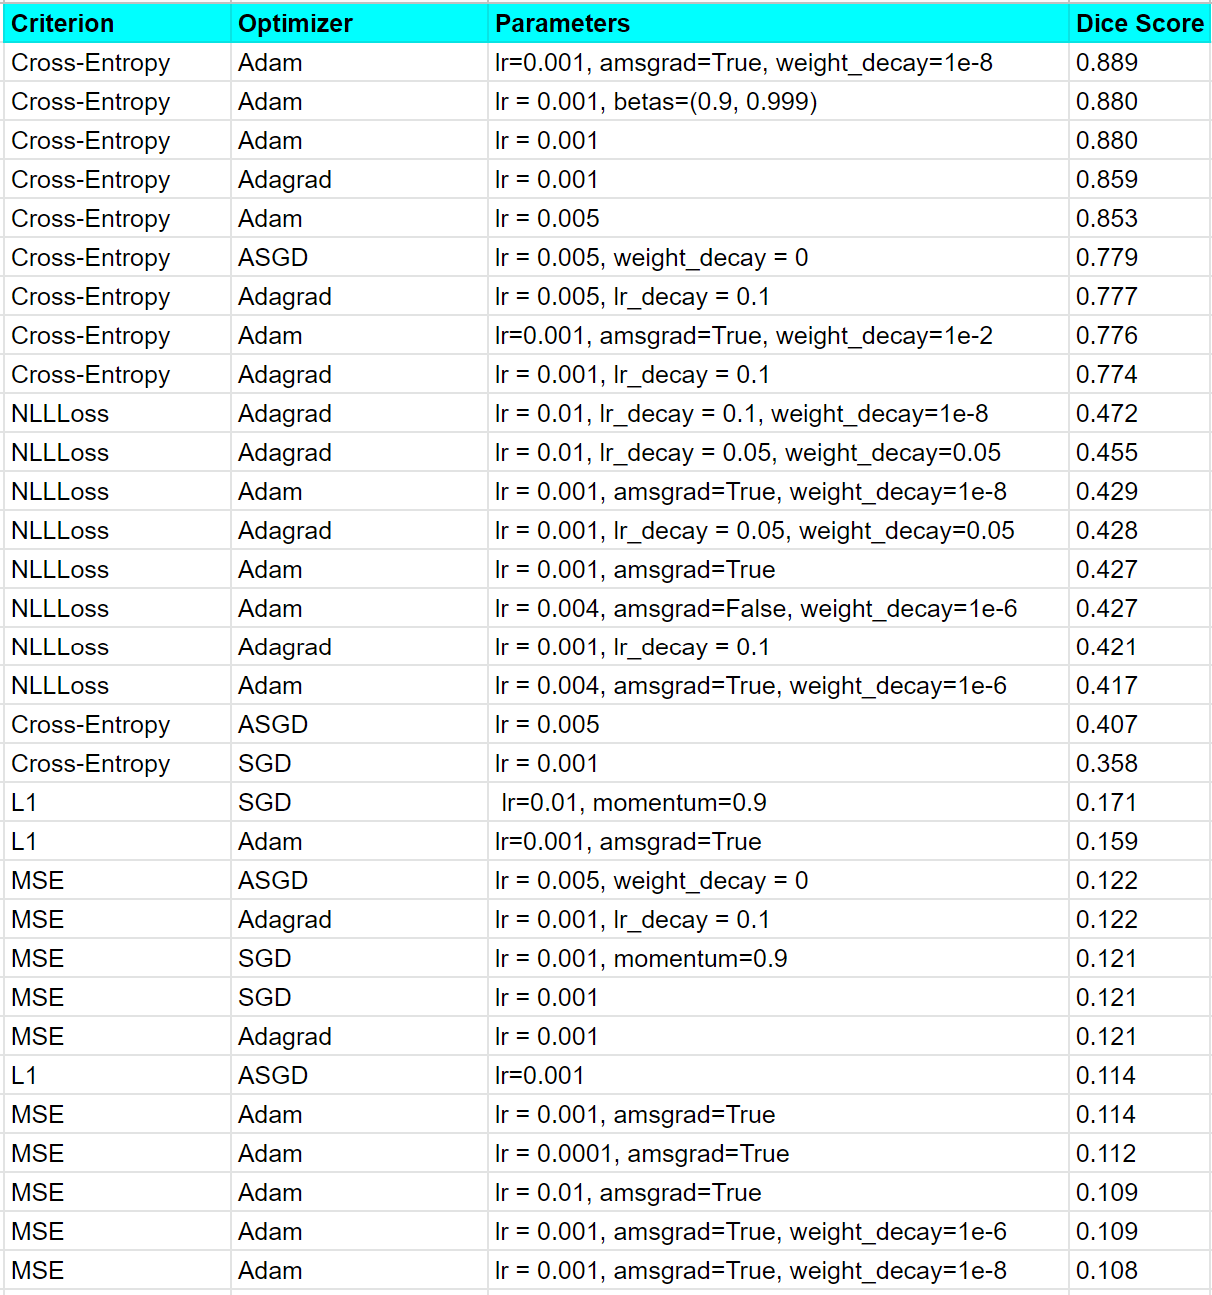
    <figcaption style="text-align: left;">Table 2: Performance hyper-parameter tuning with the following default values for the optimiser functions (PyTorch, n.d.):</figcaption>
    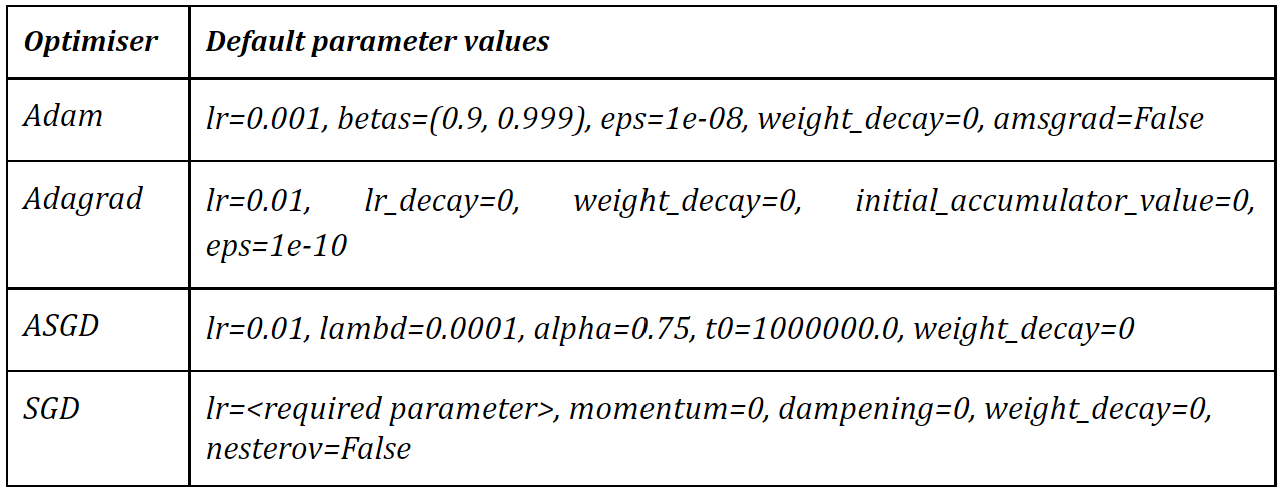
</figure>


<h2 id="conclusion">Conclusion</h2>

After all of our experiments, we found that using the base U-Net architecture with Cross-Entropy loss and the ADAM optimiser with learning rate 0.001, amsgrad set to True and weight_decay set to 1e-8 proved the most fruitful generalisation performance.

To arrive at this conclusion, we experimented with altering the model’s structure by tweaking the number of layers and using various dropout values. However, as mentioned above, the best results were given by the standard U-Net model. This proved that tuning the model’s structure was not crucial to improving how well it does.

The resulting model that made use of these parameters gave us an average dice score ranging between 0.880 to 0.889. Without the use of these two extra parameters, i.e. using only learning rate of 0.001, the average dice score performed slightly worse, thus we did not choose this model.

After many iterations of tuning the model differently, we found that there seemed to be a threshold of what was achievable for the dice-score. There seemed to be a limit of how high a dice score could be achieved before the model overfit the validation and so for it to be a well performing, generalised model, the highest value we could achieve was ≈ 0.90.

Overall, we are very pleased with the generalisation of the model, and believe that the model performs well enough to be used practically in medical services with minimal problems.

<h2 id="references">References</h2>

<ul>
    <li>
        Huan, T. (2020, May 17). simple-pytorch-fcn. GitHub. <a href="https://github.com/tangh/simple-pytorch-fcn">https://github.com/tangh/simple-pytorch-fcn</a>
    </li>
    <li>
        Lambda, H. (2019, February 17). Understanding Semantic Segmentation with UNET | by Harshall Lamba. Towards Data Science. Retrieved November 28, 2021, from <a href="https://towardsdatascience.com/understanding-semantic-segmentation-with-unet-6be4f42d4b47
">https://towardsdatascience.com/understanding-semantic-segmentation-with-unet-6be4f42d4b47</a>
    </li>
    <li>
        Ronneberger, O., Fischer, P., & Brox, T. (2011). U-Net: Convolutional Networks for Biomedical Image Segmentation. Computer Vision Group, Freiburg. Retrieved November 19, 2021, from <a href="https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/
">https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/
</a>
    </li>
    <li>
        Tsang, S.-H. (2018, October 5). Review: FCN — Fully Convolutional Network (Semantic Segmentation) | by Sik-Ho Tsang. Towards Data Science. Retrieved November 23, 2021, from <a href="https://towardsdatascience.com/review-fcn-semantic-segmentation-eb8c9b50d2d1
">https://towardsdatascience.com/review-fcn-semantic-segmentation-eb8c9b50d2d1
</a>
    </li>
</ul>

<h2 id="source-code">Source Code</h2>

### Imports

In [1]:
import os
import cv2
from matplotlib import pyplot as plt
import numpy as np
from glob import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
from torch.utils.data import DataLoader

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"The current device is {device}")

The current device is cuda:0


### Define DataLoaders

In [2]:
class TrainDataset(data.Dataset):
    def __init__(self, root=''):
        super(TrainDataset, self).__init__()
        self.img_files = glob(os.path.join(root,'image','*.png'))
        self.mask_files = []
        for img_path in self.img_files:
            basename = os.path.basename(img_path)
            self.mask_files.append(os.path.join(root,'mask',basename[:-4]+'_mask.png'))
            

    def __getitem__(self, index):
            img_path = self.img_files[index]
            mask_path = self.mask_files[index]
            data = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
            label = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
            return torch.from_numpy(data).float(), torch.from_numpy(label).float()

    def __len__(self):
        return len(self.img_files)


class TestDataset(data.Dataset):
    def __init__(self, root=''):
        super(TestDataset, self).__init__()
        self.img_files = glob(os.path.join(root,'image','*.png'))

    def __getitem__(self, index):
            img_path = self.img_files[index]
            data = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
            return torch.from_numpy(data).float(), img_path.split('/')[-1].split('.')[0]

    def __len__(self):
        return len(self.img_files)

### Define a Segmenatation Model using U-Net 

In [3]:
class ConvBlock(nn.Module):

    def __init__(self, in_ch, out_ch):
        super(ConvBlock, self).__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)


class Encoder(nn.Module):

    def __init__(self, in_ch, out_ch):
        super(Encoder, self).__init__()
        self.down = nn.Sequential(
            nn.MaxPool2d(2),
            ConvBlock(in_ch, out_ch)
        )

    def forward(self, x):
        return self.down(x)
    

class Decoder(nn.Module):

    def __init__(self, in_ch, out_ch):
        super(Decoder, self).__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = ConvBlock(in_ch, out_ch)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)
    

class OutConv(nn.Module):
    
    def __init__(self, in_ch, out_ch):
        super(OutConv, self).__init__()
        self.output = nn.Conv2d(in_ch, out_ch, kernel_size=1)

    def forward(self, x):
        return self.output(x)
    

class UNet(nn.Module):
    
    def __init__(self):
        super(UNet, self).__init__()
        # Input
        self.input = ConvBlock(1, 64)
        
        # Encoder
        self.encoder1 = Encoder(64, 128)
        self.encoder2 = Encoder(128, 256)
        self.encoder3 = Encoder(256, 512)
        self.encoder4 = Encoder(512, 1024)

        # Decoder
        self.decoder1 = Decoder(1024, 512)
        self.decoder2 = Decoder(512, 256)
        self.decoder3 = Decoder(256, 128)
        self.decoder4 = Decoder(128, 64)
        
        # Output
        self.output = OutConv(64, 4)

    def forward(self, x):
        e1 = self.input(x)
        e2 = self.encoder1(e1)
        e3 = self.encoder2(e2)
        e4 = self.encoder3(e3)
        e5 = self.encoder4(e4)

        d1 = self.decoder1(e5, e4)
        d2 = self.decoder2(d1, e3)
        d3 = self.decoder3(d2, e2)
        d4 = self.decoder4(d3, e1)
        
        return self.output(d4)

model = UNet()
model.to(device);

### Load datasets

In [4]:
# Path to training data
training_data_path = './data/train'

# Path to validating data
val_data_path = './data/val'

# Path to the test dataset
test_data_path = './data/test'

# Define the number of workers used by Pytorch
num_workers = 4

# Define the number of batches for the DataLoader
batch_size = 4

# Loading training dataset
train_set = TrainDataset(training_data_path)
training_data_loader = DataLoader(dataset=train_set, num_workers=num_workers, batch_size=batch_size, shuffle=True)

# Loading validation dataset
val_set = TrainDataset(val_data_path)
val_data_loader = DataLoader(dataset=val_set, num_workers=num_workers, batch_size=batch_size, shuffle=True)

# Loading testing dataset
test_set = TestDataset(test_data_path)
test_data_loader = DataLoader(dataset=test_set, num_workers=num_workers, batch_size=batch_size, shuffle=False)

### Define helper functions

In [5]:
def categorical_dice(mask1, mask2, label_class=1):
    """
    Dice score of a specified class between two volumes of label masks.
    (classes are encoded but by label class number not one-hot )
    Note: stacks of 2D slices are considered volumes.

    Args:
        mask1: N label masks, numpy array shaped (H, W, N)
        mask2: N label masks, numpy array shaped (H, W, N)
        label_class: the class over which to calculate dice scores

    Returns:
        volume_dice
    """
    mask1_pos = (mask1 == label_class).astype(np.float32)
    mask2_pos = (mask2 == label_class).astype(np.float32)
    dice = 2 * np.sum(mask1_pos * mask2_pos) / (np.sum(mask1_pos) + np.sum(mask2_pos))
    return dice

def average_dice_score(pred, target):
    """
    Calculate the mean of dice score for all label classes.

    Args:
        pred: numpy array shaped (H, W)
        target: numpy array shaped (H, W)
    Returns:
        dice_score_mean
    """
    return np.mean([
        categorical_dice(pred, target, 1),
        categorical_dice(pred, target, 2),
        categorical_dice(pred, target, 3)
    ])

def dice_score(pred, target):
    """
    Calculate the dice score on batch.

    Args:
        pred: numpy array shaped (B, C, H, W)
        target: numpy array shaped (B, H, W)
    Returns:
        dice_score
    """
    
    score = 0
    
    for i in range(pred.shape[0]):
        score += average_dice_score(target[i].cpu().detach().numpy(), pred[i].argmax(axis=0).cpu().detach().numpy())

    return score / pred.shape[0]

In [6]:
def train(training_data_loader):
    """
    Train the model on provided dataset

    Args:
        training_data_loader: DataLoader
    Returns:
        training_loss
    """
    
    model.train()
    training_loss = 0
    
    for i, sample in enumerate(training_data_loader):
        # get the inputs
        image, target = (sample[0].unsqueeze(1).to(device=device), sample[1].long().to(device=device))
        
        # zero the parameter gradients
        optimizer.zero_grad()
        
        # forward + backward + optimize
        pred = model(image)
        loss = criterion(pred, target)
        loss.backward()
        optimizer.step()
        training_loss += loss.item()

    return training_loss

In [7]:
def validate(val_data_loader):
    """
    Validate the model on provided dataset

    Args:
        val_data_loader: DataLoader
    Returns:
        valid_loss, score
    """
    
    model.eval()
    score = 0
    valid_loss = 0
    
    with torch.no_grad():
        for i, sample in enumerate(val_data_loader):
            # get the inputs
            image, target = (sample[0].unsqueeze(1).to(device=device), sample[1].long().to(device=device))

            # Forward Pass
            pred = model(image)

            score += dice_score(pred, target)
            loss = criterion(pred, target)
            valid_loss += loss.item()
            
    return valid_loss, score

### Define a Loss function and optimizer

In [8]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimisation algorithm
optimizer = optim.Adam(model.parameters(), lr=0.001, amsgrad=True, weight_decay=1e-8)

### Train, Validate, Test

In [9]:
# Define the number of epochs
EPOCHS = 100

max_dice_score = 0

# Training loop
for epoch in range(EPOCHS):
    # Training Block
    training_loss = train(training_data_loader)
    
    # Validation Block
    valid_loss, score = validate(val_data_loader)
    
    # Print logs for each epoch
    print('Epoch: {}, \
          Training Loss: {:.6f}, \
          Valid Loss: {:.6f}, \
          Dice Score: {:.6f}'.format(epoch+1,
                                     training_loss/len(training_data_loader),
                                     valid_loss/len(val_data_loader),
                                     score/len(val_data_loader)))
    
    # Save checkpoint if epoch dice score high than max dice score
    if max_dice_score < score/len(val_data_loader):
        print('Dice Score Increased {:.6f} -> {:.6f}'.format(max_dice_score, score/len(val_data_loader)))
        max_dice_score = score/len(val_data_loader)
        
        print('Saving the model')
        # Saving State Dict
        torch.save(model.state_dict(), 'saved_model.pth')

Epoch: 1,           Training Loss: 1.020634,           Valid Loss: 31.709321,           Dice Score: 0.046423
Dice Score Increased 0.000000 -> 0.046423
Saving the model
Epoch: 2,           Training Loss: 0.503054,           Valid Loss: 0.830373,           Dice Score: 0.444213
Dice Score Increased 0.046423 -> 0.444213
Saving the model
Epoch: 3,           Training Loss: 0.304153,           Valid Loss: 0.399802,           Dice Score: 0.555236
Dice Score Increased 0.444213 -> 0.555236
Saving the model
Epoch: 4,           Training Loss: 0.221903,           Valid Loss: 0.272348,           Dice Score: 0.691593
Dice Score Increased 0.555236 -> 0.691593
Saving the model
Epoch: 5,           Training Loss: 0.190326,           Valid Loss: 0.169090,           Dice Score: 0.715115
Dice Score Increased 0.691593 -> 0.715115
Saving the model
Epoch: 6,           Training Loss: 0.151642,           Valid Loss: 0.188032,           Dice Score: 0.674143
Epoch: 7,           Training Loss: 0.135309,           V

In [10]:
# Load the best saved checkpoint
model = UNet()
model.to(device);
model.load_state_dict(torch.load('./saved_model.pth'))
model.eval();

### Evaluation
Evaluate the saved checkpoint

In [11]:
# Print the dice score acheived by the saved checkpoint
validate(val_data_loader)[1] / len(val_data_loader)

0.8882506772987331

### Testing

In [12]:
# Set the mode to evaluation
model.eval()

# Prediction loop
for i, sample in enumerate(test_data_loader):
    image, filename = sample[0].unsqueeze(1).to(device=device), sample[1]
    pred = model(image)
    
    # Save the predicted masks using OpenCV
    for j in range(pred.shape[0]):
        cv2.imwrite(os.path.join('./data/test', 'mask', filename[j] +'_mask.png'), pred[j].argmax(axis=0).cpu().detach().numpy())